# T³ CAN: Activity Manifold Topology


Quick notebook for devlopment of the T^3 torus. Checking if the CAN produces the expected activity Manifold. Following the structure of the MADE tutorial:

https://github.com/FieteLab/MADE/blob/main/made/notebooks/2_visualize_activity_manifold.ipynb


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from loguru import logger
from persim import plot_diagrams

sys.path.insert(0, os.path.abspath("../../.."))

from spatial_nav.CAN_IMP import torus3D_manifold, visualize3D, utils3D
from spatial_nav.CAN_IMP.CAN3D import CAN3D


# Set parameters and build the CAN

In [2]:
# Network and simulation parameters (best config from the parameter sweep
# in 2_5_visualise_connect.ipynb; locked in here for reproducibility)
N_SAMPLES          = 25      # total seeds = N_SAMPLES**3
N_SIMULATION_STEPS = 150
SPACING            = 0.4

ALPHA = 0.8
SIGMA = 1.5
B     = 1.6

# Clamping parameters
USE_CLAMP           = True
CLAMP_FRACTION      = 0.15
CLAMP_RADIUS_FACTOR = 1.5

# Build CAN
manifold = torus3D_manifold.Torus3D()
can = CAN3D(manifold, spacing=SPACING, alpha=ALPHA, sigma=SIGMA, b=B)
print(can)


CAN3D(manifold=Torus3D(dim=3, parameter_space=ParameterSpace3D(ranges=[Range(start=0, end=6.283185307179586, periodic=True), Range(start=0, end=6.283185307179586, periodic=True), Range(start=0, end=6.283185307179586, periodic=True)]), metric=<made.metrics.PeriodicEuclidean object at 0x13036ced0>), spacing=0.4, alpha=0.8, sigma=1.5, tau=5, weights_offset=<function default_weights_offset at 0x12de17560>, b=1.6)


## Simulations
Use the created T^3, sample some points over the parameter space and run simulations with activity bumps at these points. Seeing where the bump settles


2026-05-01 22:02:34.450 | INFO     | __main__:<module>:6 - Samples: (15625, 3), range [0.00, 6.03]


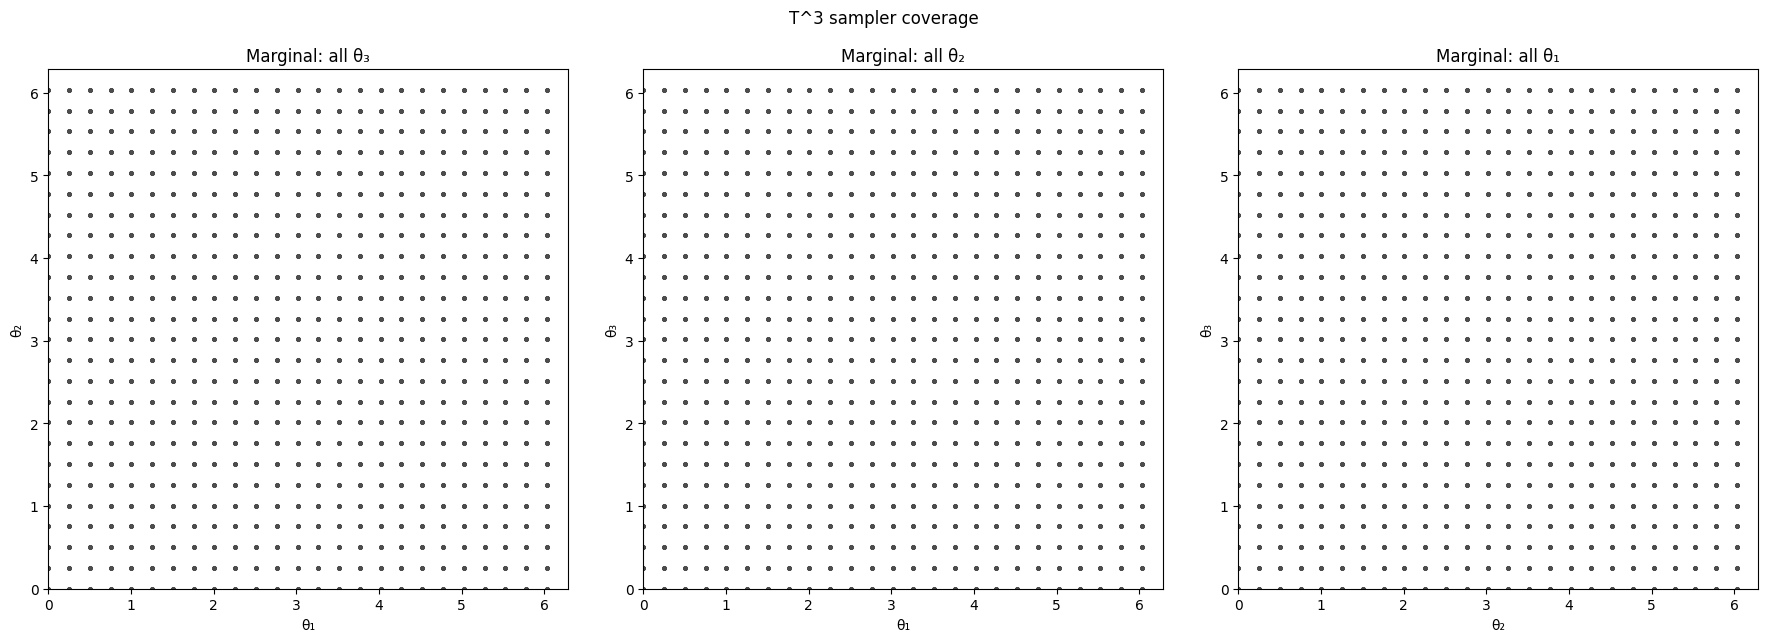

In [3]:
# Sample point from the parameterspace (not neurons, but points)
samples = can.manifold.parameter_space.sample(N_SAMPLES, pads=[0.0, 0.0, 0.0])

# Shuffle so downstream do not see ordered points
samples = samples[np.random.default_rng(seed=42).permutation(len(samples))]
logger.info(
    f"Samples: {samples.shape}, "
    f"range [{samples.min():.2f}, {samples.max():.2f}]"
)

#Plot T^3, plot the samples
visualize3D._plot_marginals(
    samples, "T^3 sampler coverage",
    color=[0.3, 0.3, 0.3], alpha=0.3, s=5,
)


In [4]:
#Takes the sampled points (looping over) , turn on the neurons close to these points 
#let the reccurent dynamics of the CAN network take over. 
final_states = utils3D.simulate_many(
    samples, can, N_SIMULATION_STEPS,
    use_clamp=USE_CLAMP,
    clamp_fraction=CLAMP_FRACTION,
    clamp_radius_factor=CLAMP_RADIUS_FACTOR,
)
logger.info(f"Final states shape: {final_states.shape}")


Simulating bumps: 100%|██████████| 15625/15625 [2:17:20<00:00,  1.90sample/s]  
2026-05-02 00:20:02.079 | INFO     | __main__:<module>:9 - Final states shape: (15625, 4096)


# Visualize bump positions

Visualize the bump positions, we want them to settle at the same points (as the grey above).



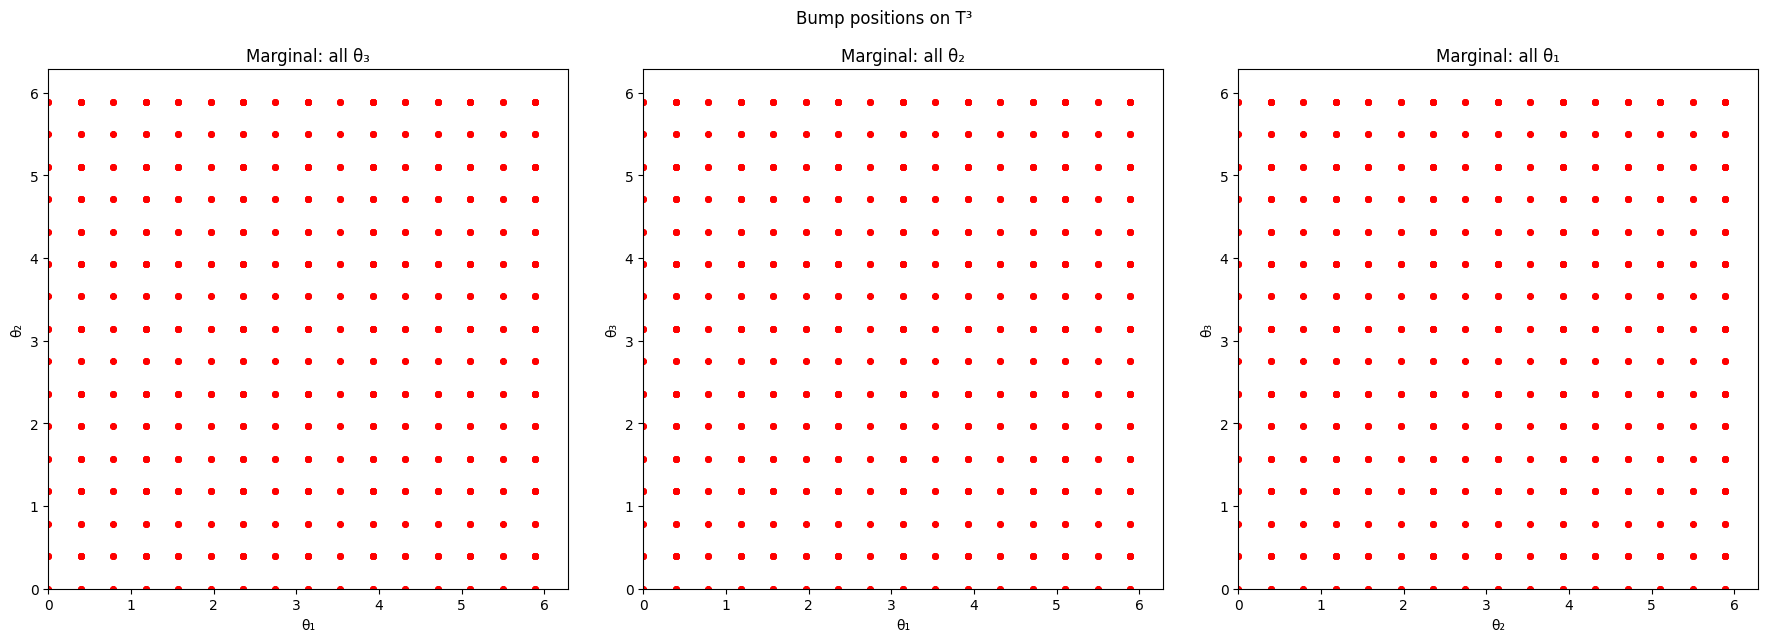

In [5]:
bump_coords = utils3D.extract_bump_coords(final_states, can)

visualize3D._plot_marginals(
    bump_coords, "Bump positions on T³",
    color="red", alpha=0.5, s=12,
)


## 3. Visualize the activity manifold
Use PCA (dimensionality reduction) who takes each bump state witch is a point in 2197 dimensional space (n = 13) and reduces this down to 3 numbers (theta_1, theta_2 and theta_3). Since we want to vosualise the slice in 3D we also need curvature, so we use 50 components

Then takes this reduction and finds a 3D representasion based on how far each of these points are from eachother.

reconstruction error 12.1878
reconstruction error 11.4727
reconstruction error 11.2200
reconstruction error 12.1684


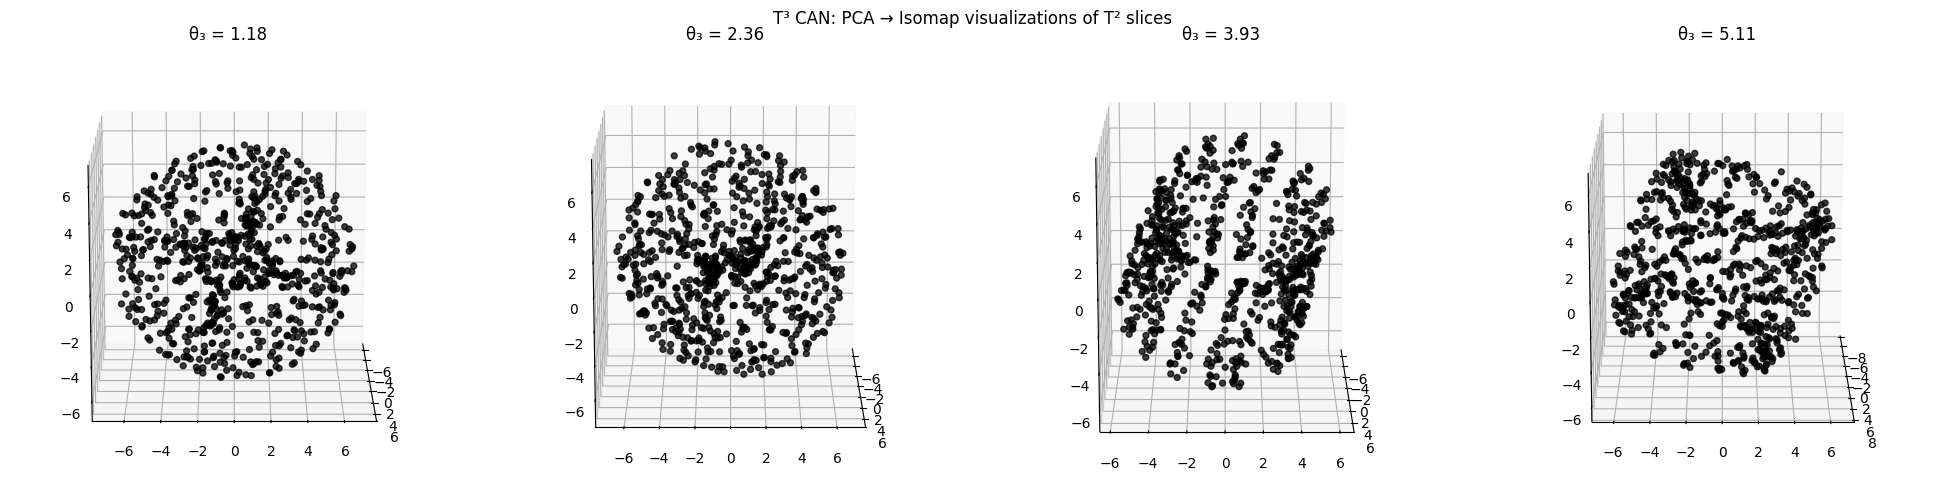

In [6]:
# View angles for the 3D Isomap scatter — adjust until the donut shape is visible
ELEV = 15
AZIM = 0

visualize3D.plot_isomap_slices(
    final_states, bump_coords, can,
    n_slices=4,
    elev=ELEV, azim=AZIM,
)
plt.show()
